# Урок 13. Продвинутые задачи

**Интерактивная версия:** `lessons/lesson_13/web/index.html`

Точность, ECE и log-loss переобучающегося бустинга; диаграмма надёжности.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


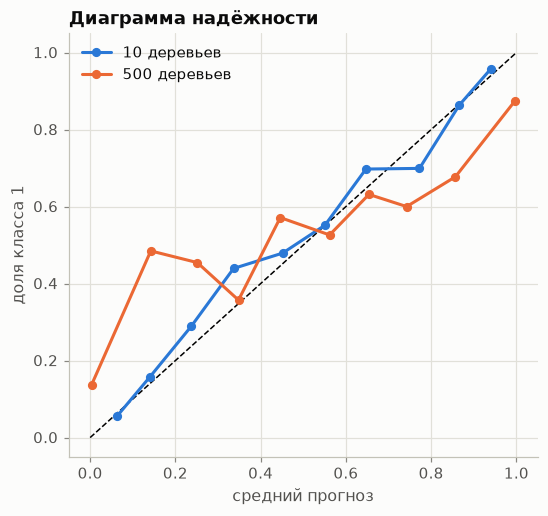

,деревьев,точность,ECE,log-loss
0,10,0.8723,0.0207,0.3258
1,30,0.8673,0.0532,0.3525
2,100,0.8653,0.0880,0.4711
3,300,0.8543,0.1200,0.8361
4,500,0.8527,0.1298,1.2322


In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gbcourse import datasets, GBClassifier
from gbcourse.plotting import use_course_style

use_course_style()
X, y = datasets.classification_2d(kind="moons", n=600, noise=0.35, seed=190)
X_te, y_te = datasets.classification_2d(kind="moons", n=3000, noise=0.35, seed=191)
model = GBClassifier(n_estimators=500, learning_rate=0.3, max_depth=4).fit(X, y)


def reliability(y, p, bins=10):
    idx = np.minimum((p * bins).astype(int), bins - 1)
    return [(p[idx == b].mean(), y[idx == b].mean(), int(np.sum(idx == b))) for b in range(bins) if np.any(idx == b)]


def ece(y, p, bins=10):
    return sum(n / len(p) * abs(c - a) for c, a, n in reliability(y, p, bins))


rows = []
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], "k--", lw=1)
for k in (10, 30, 100, 300, 500):
    p = 1 / (1 + np.exp(-model.predict_raw(X_te, k)))
    rows.append({"деревьев": k, "точность": np.mean((p > 0.5) == y_te), "ECE": ece(y_te, p),
                 "log-loss": -np.mean(y_te * np.log(p) + (1 - y_te) * np.log(1 - p))})
    if k in (10, 500):
        r = np.array(reliability(y_te, p))
        ax.plot(r[:, 0], r[:, 1], marker="o", label=f"{k} деревьев")
ax.set(xlabel="средний прогноз", ylabel="доля класса 1", title="Диаграмма надёжности")
ax.legend()
plt.show()
pd.DataFrame(rows).round(4)

## Упражнения

1. Повторите опыт с ν = 0.05 и 500 деревьями. Растёт ли ECE так же быстро?
2. Остановите обучение по log-loss на валидации. Какое ECE у остановленной модели?

Решения: `python lessons/lesson_13/exercises/solutions.py`.